# NIFTY Intelligence Data Analysis

This notebook explores the `KaggleData` folder, which contains:

- one combined market history file: `NIFTY50_all.csv`
- per-symbol stock history files
- a metadata file with company and industry information

The analysis below focuses on three things:

1. data coverage and quality
2. price and return behavior across symbols
3. volume and volatility patterns

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

base_dir = Path.cwd()
data_dir = base_dir / "KaggleData"

stock_files = sorted(
    path for path in data_dir.glob("*.csv")
    if path.name not in {"NIFTY50_all.csv", "stock_metadata.csv"}
)

metadata_path = data_dir / "stock_metadata.csv"
master_path = data_dir / "NIFTY50_all.csv"

print(f"Found {len(stock_files)} per-symbol files")
print(f"Master file exists: {master_path.exists()}")
print(f"Metadata file exists: {metadata_path.exists()}")

frames = []
for file_path in stock_files:
    frame = pd.read_csv(file_path, parse_dates=["Date"])
    frame["source_file"] = file_path.name
    frames.append(frame)

stocks = pd.concat(frames, ignore_index=True)

numeric_columns = [
    "Prev Close", "Open", "High", "Low", "Last", "Close", "VWAP",
    "Volume", "Turnover", "Trades", "Deliverable Volume", "%Deliverble",
]
for column in numeric_columns:
    if column in stocks.columns:
        stocks[column] = pd.to_numeric(stocks[column], errors="coerce")

stocks["Symbol"] = stocks["Symbol"].fillna(stocks["source_file"].str.replace(".csv", "", regex=False))
stocks = stocks.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Combined rows:", len(stocks))
print("Columns:", list(stocks.columns))
display(stocks.head())

Found 50 per-symbol files
Master file exists: True
Metadata file exists: True
Combined rows: 235192
Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'source_file']


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble,source_file
0,2012-01-17 00:00:00,ADANIPORTS,EQ,135.5,137.1,141.00,135.00,140.1,140.00,138.13,1636196,2.260074e+13,18374.0,1004327.0,0.6138,ADANIPORTS.csv
1,2012-01-18 00:00:00,ADANIPORTS,EQ,140.0,142.0,143.80,138.70,143.0,141.70,141.25,890591,1.257986e+13,15615.0,404925.0,0.4547,ADANIPORTS.csv
2,2012-01-19 00:00:00,ADANIPORTS,EQ,141.7,144.0,150.55,143.15,149.5,149.40,146.72,1456077,2.136382e+13,31299.0,721545.0,0.4955,ADANIPORTS.csv
3,2012-01-20 00:00:00,ADANIPORTS,EQ,149.4,151.9,157.60,150.25,155.4,155.40,153.76,1634070,2.512583e+13,23335.0,861145.0,0.5270,ADANIPORTS.csv
4,2012-01-23 00:00:00,ADANIPORTS,EQ,155.4,155.4,155.40,145.10,146.4,146.75,149.54,1657609,2.478768e+13,12400.0,820653.0,0.4951,ADANIPORTS.csv


## 1. Data coverage and quality

In [2]:
metadata = pd.read_csv(metadata_path)
metadata["Symbol"] = metadata["Symbol"].astype(str)

stocks = stocks.copy()
stocks["daily_return"] = stocks.groupby("Symbol")["Close"].pct_change()

symbol_summary = (
    stocks.groupby("Symbol")
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        trading_days=("Date", "size"),
        first_close=("Close", "first"),
        last_close=("Close", "last"),
        avg_close=("Close", "mean"),
        min_close=("Close", "min"),
        max_close=("Close", "max"),
        avg_volume=("Volume", "mean"),
        median_volume=("Volume", "median"),
        avg_turnover=("Turnover", "mean"),
        return_volatility=("daily_return", "std"),
        avg_daily_return=("daily_return", "mean"),
    )
    .reset_index()
)

symbol_summary["total_return_pct"] = (symbol_summary["last_close"] / symbol_summary["first_close"] - 1) * 100
symbol_summary = symbol_summary.merge(metadata[["Symbol", "Company Name", "Industry"]], on="Symbol", how="left")

missing_values = stocks.isna().sum().sort_values(ascending=False).rename("missing_count")
missing_values = missing_values[missing_values > 0].to_frame()

print(f"Symbols in combined file: {symbol_summary['Symbol'].nunique()}")
print(f"Date range: {stocks['Date'].min().date()} to {stocks['Date'].max().date()}")
print(f"Rows with missing values in Trades: {stocks['Trades'].isna().sum()}")
print(f"Rows with missing values in Deliverable Volume: {stocks['Deliverable Volume'].isna().sum()}")

print("\nTop 10 symbols by total return")
display(symbol_summary.sort_values("total_return_pct", ascending=False).head(10)[["Symbol", "Company Name", "Industry", "total_return_pct", "trading_days"]])

print("\nBottom 10 symbols by total return")
display(symbol_summary.sort_values("total_return_pct", ascending=True).head(10)[["Symbol", "Company Name", "Industry", "total_return_pct", "trading_days"]])

print("\nMissing values summary")
display(missing_values)

Symbols in combined file: 65
Date range: 2000-01-03 to 2021-04-30
Rows with missing values in Trades: 114848
Rows with missing values in Deliverable Volume: 16077

Top 10 symbols by total return


,Symbol,Company Name,Industry,total_return_pct,trading_days
47,SHREECEM,Shree Cement Ltd.,CEMENT & CEMENT PRODUCTS,43005.019305,4985
14,EICHERMOT,Eicher Motors Ltd.,AUTOMOBILE,4857.318321,5301
38,MARUTI,Maruti Suzuki India Ltd.,AUTOMOBILE,3829.184419,4427
27,INDUSINDBK,IndusInd Bank Ltd.,FINANCIAL SERVICES,3129.533679,4985
57,ULTRACEMCO,UltraTech Cement Ltd.,CEMENT & CEMENT PRODUCTS,2313.124520,4140
60,UTIBANK,NaN,NaN,2137.827715,1912
4,BAJAJFINSV,Bajaj Finserv Ltd.,FINANCIAL SERVICES,2068.856806,3201
5,BAJAUTOFIN,NaN,NaN,1463.743842,2611
25,HINDUNILVR,Hindustan Unilever Ltd.,CONSUMER GOODS,1089.964611,3413
34,KOTAKBANK,Kotak Mahindra Bank Ltd.,FINANCIAL SERVICES,1026.804124,4483



Bottom 10 symbols by total return


,Symbol,Company Name,Industry,total_return_pct,trading_days
24,HINDLEVER,NaN,NaN,-91.384802,1893
39,MUNDRAPORT,NaN,NaN,-85.927926,1023
22,HINDALC0,NaN,NaN,-83.630180,1919
62,WIPRO,Wipro Ltd.,IT,-81.912121,5306
28,INFOSYSTCH,NaN,NaN,-81.662315,2870
64,ZEETELE,NaN,NaN,-79.799992,1796
58,UNIPHOS,NaN,NaN,-71.505959,2429
31,ITC,ITC Ltd.,CONSUMER GOODS,-71.404375,5306
30,IOC,Indian Oil Corporation Ltd.,ENERGY,-66.457449,5306
49,SUNPHARMA,Sun Pharmaceutical Industries Ltd.,PHARMA,-64.336122,5306



Missing values summary


,missing_count
Trades,114848
%Deliverble,16077
Deliverable Volume,16077
daily_return,65


## 2. Return and volatility patterns

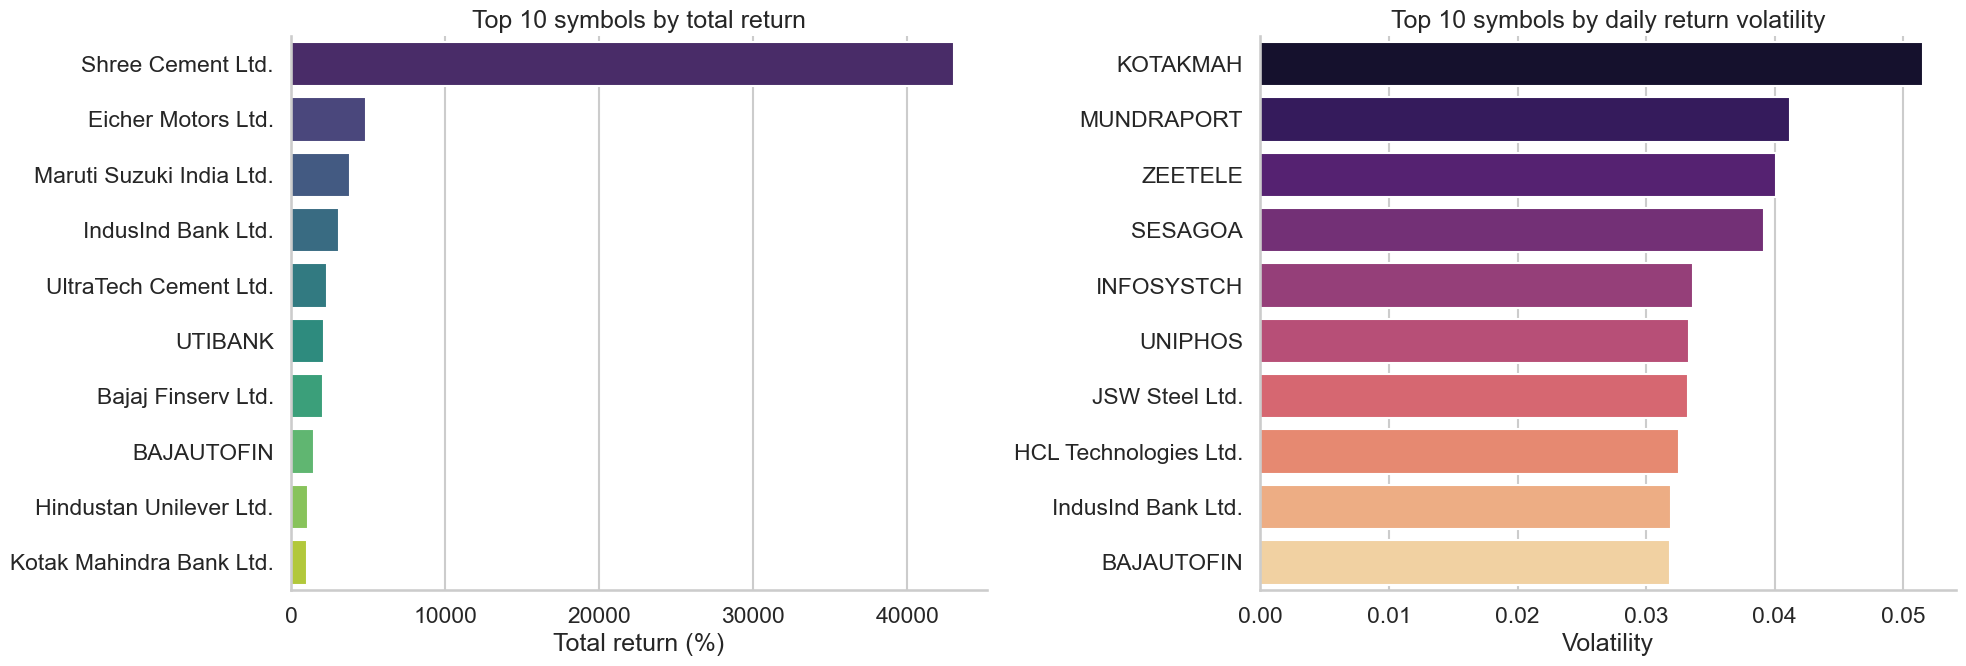

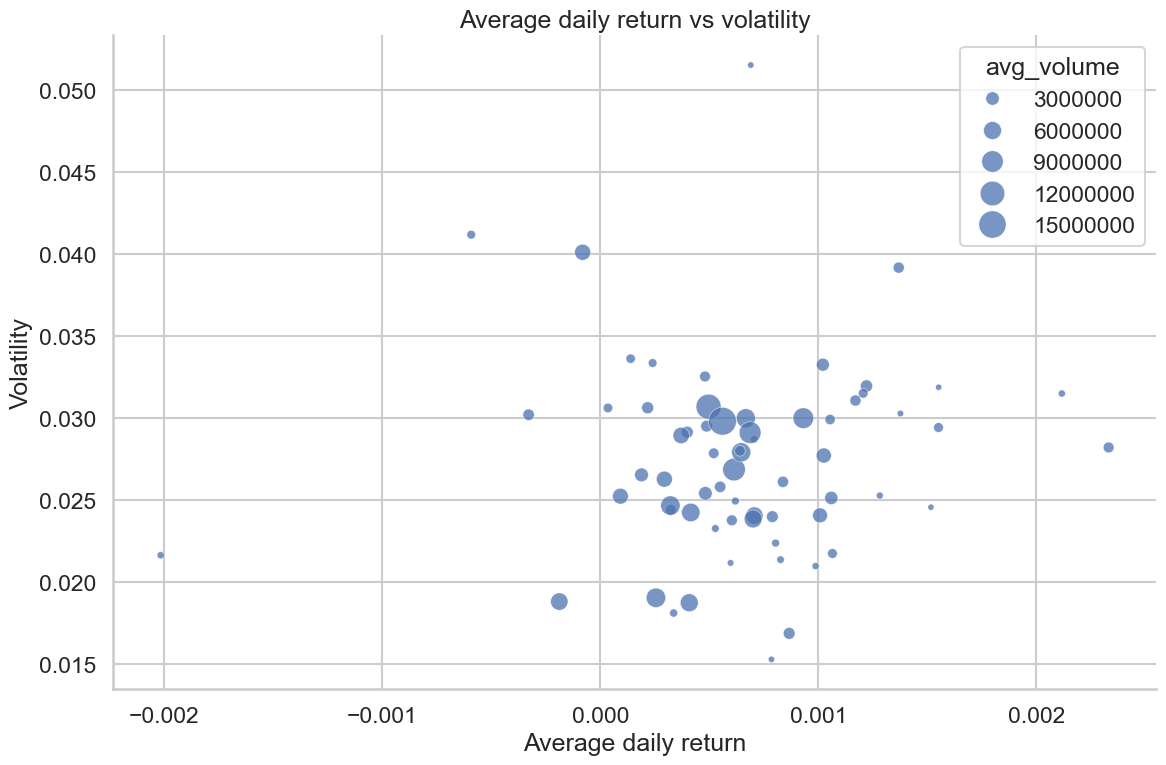

,Symbol,display_name,Industry,total_return_pct,return_volatility,avg_volume
35,KOTAKMAH,KOTAKMAH,NaN,-36.232832,0.051523,7.176370e+04
39,MUNDRAPORT,MUNDRAPORT,NaN,-85.927926,0.041174,8.090038e+05
64,ZEETELE,ZEETELE,NaN,-79.799992,0.040101,4.674488e+06
46,SESAGOA,SESAGOA,NaN,61.710357,0.039163,1.810788e+06
28,INFOSYSTCH,INFOSYSTCH,NaN,-81.662315,0.033606,1.030852e+06
58,UNIPHOS,UNIPHOS,NaN,-71.505959,0.033343,7.926438e+05
32,JSWSTEEL,JSW Steel Ltd.,METALS,128.214910,0.033242,2.756313e+06
17,HCLTECH,HCL Technologies Ltd.,IT,-42.169256,0.032522,1.645121e+06
27,INDUSINDBK,IndusInd Bank Ltd.,FINANCIAL SERVICES,3129.533679,0.031942,2.351251e+06
5,BAJAUTOFIN,BAJAUTOFIN,NaN,1463.743842,0.031864,1.899630e+04


In [5]:
plot_summary = symbol_summary.copy()
plot_summary["display_name"] = plot_summary["Company Name"].fillna(plot_summary["Symbol"])

volatility_table = plot_summary.sort_values("return_volatility", ascending=False).head(10)
performance_table = plot_summary.sort_values("total_return_pct", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.barplot(
    data=performance_table,
    x="total_return_pct",
    y="display_name",
    hue="display_name",
    palette="viridis",
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Top 10 symbols by total return")
axes[0].set_xlabel("Total return (%)")
axes[0].set_ylabel("")

sns.barplot(
    data=volatility_table,
    x="return_volatility",
    y="display_name",
    hue="display_name",
    palette="magma",
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Top 10 symbols by daily return volatility")
axes[1].set_xlabel("Volatility")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=plot_summary,
    x="avg_daily_return",
    y="return_volatility",
    size="avg_volume",
    sizes=(20, 400),
    alpha=0.75,
    ax=ax,
)
ax.set_title("Average daily return vs volatility")
ax.set_xlabel("Average daily return")
ax.set_ylabel("Volatility")
plt.tight_layout()
plt.show()

display(
    plot_summary[["Symbol", "display_name", "Industry", "total_return_pct", "return_volatility", "avg_volume"]]
    .sort_values("return_volatility", ascending=False)
    .head(15)
)

## 3. Price and volume trends

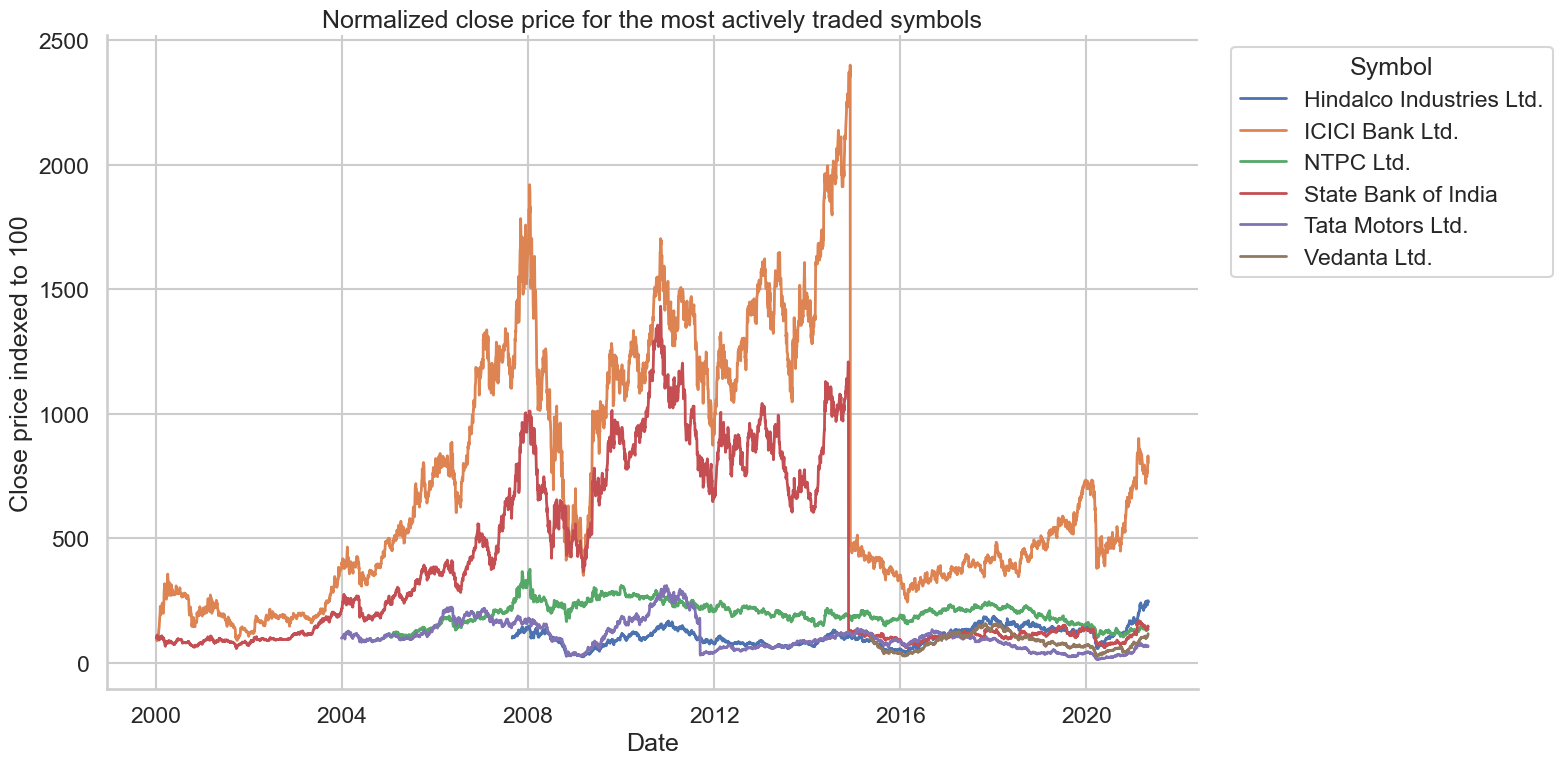

Top symbols by average volume


,Symbol,display_name,Industry,avg_volume,trading_days
61,VEDL,Vedanta Ltd.,METALS,1.564060e+07,1482
50,TATAMOTORS,Tata Motors Ltd.,AUTOMOBILE,1.247240e+07,4307
45,SBIN,State Bank of India,FINANCIAL SERVICES,1.003930e+07,5306
23,HINDALCO,Hindalco Industries Ltd.,METALS,9.282843e+06,3387
26,ICICIBANK,ICICI Bank Ltd.,FINANCIAL SERVICES,8.224631e+06,5306
41,NTPC,NTPC Ltd.,ENERGY,7.226587e+06,4088


In [4]:
active_symbols = (
    plot_summary.sort_values("avg_volume", ascending=False)
    .head(6)
    .copy()
)

trend_subset = stocks[stocks["Symbol"].isin(active_symbols["Symbol"])]
trend_subset = trend_subset.merge(
    active_symbols[["Symbol", "display_name"]],
    on="Symbol",
    how="left",
)
trend_subset["normalized_close"] = trend_subset.groupby("Symbol")["Close"].transform(lambda series: series / series.iloc[0] * 100)

fig, ax = plt.subplots(figsize=(16, 8))
sns.lineplot(
    data=trend_subset,
    x="Date",
    y="normalized_close",
    hue="display_name",
    linewidth=2,
    ax=ax,
)
ax.set_title("Normalized close price for the most actively traded symbols")
ax.set_xlabel("Date")
ax.set_ylabel("Close price indexed to 100")
ax.legend(title="Symbol", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Top symbols by average volume")
display(active_symbols[["Symbol", "display_name", "Industry", "avg_volume", "trading_days"]])

## Key takeaways

- The combined price history spans 65 symbols from 2000-01-03 to 2021-04-30.
- `Trades` and `Deliverable Volume` are the only fields with notable missingness, so they are the main data-quality caveats.
- Long-run winners in this slice include Shree Cement, Eicher Motors, Maruti Suzuki, and IndusInd Bank.
- The most actively traded names are concentrated in banks, metals, and autos, and their normalized price paths diverge sharply over time.